# 518880 recovery drift 分布展示

这个 notebook 只读取已经生成好的 `CSV`，目标是把 `spread=2 -> 1` 恢复后的各种窗口漂移，按**分位数**和**完整分布**展示出来，而不是只看均值。

重点看三类结果：

- 固定时间窗 `time_seconds`
- 按后续非零 `mid move` 次数对齐的 `mid_moves`
- `advance_close` 和 `rollback_close` 的分布对比图


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


def locate_base_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / 'sh518880',
        Path.cwd().parent / 'sh518880',
    ]
    for base in candidates:
        if (base / 'data' / 'spread2_recovery_drift').exists():
            return base.resolve()
    raise FileNotFoundError('cannot locate sh518880/data/spread2_recovery_drift')


BASE_DIR = locate_base_dir()
DRIFT_DIR = BASE_DIR / 'data' / 'spread2_recovery_drift'

overview = pd.read_csv(DRIFT_DIR / 'overview.csv')
drift_summary = pd.read_csv(DRIFT_DIR / 'drift_summary.csv')
quantile_summary = pd.read_csv(DRIFT_DIR / 'drift_quantile_summary.csv')
value_distribution = pd.read_csv(DRIFT_DIR / 'drift_value_distribution.csv')

print(f'BASE_DIR = {BASE_DIR}')
print(f'DRIFT_DIR = {DRIFT_DIR}')


BASE_DIR = /home/jovyan/work/tactics_demo/sh518880
DRIFT_DIR = /home/jovyan/work/tactics_demo/sh518880/data/spread2_recovery_drift


## 1. 样本概览

In [2]:
display(overview)

display(
    drift_summary[
        [
            'horizon_type',
            'horizon_value',
            'resolution_path',
            'samples',
            'mean_signed_drift_tick',
            'median_signed_drift_tick',
            'continue_ratio',
            'reverse_ratio',
            'flat_ratio',
        ]
    ].head(12)
)


,trade_days,panel_rows,episodes_total,advance_close_samples,rollback_close_samples
0,49,705331,29530,15210,14320


,horizon_type,horizon_value,resolution_path,samples,mean_signed_drift_tick,median_signed_drift_tick,continue_ratio,reverse_ratio,flat_ratio
0,mid_moves,1,advance_close,15206,-0.1901,-0.5000,0.3889,0.6111,0.0000
1,mid_moves,1,rollback_close,14319,0.2411,0.5000,0.6346,0.3654,0.0000
2,mid_moves,2,advance_close,15201,-0.0569,-0.0000,0.2771,0.3391,0.3838
3,mid_moves,2,rollback_close,14316,0.1592,0.0000,0.3624,0.2492,0.3884
4,mid_moves,3,advance_close,15197,-0.0420,0.0000,0.4103,0.4793,0.1104
5,mid_moves,3,rollback_close,14314,0.1949,0.5000,0.5138,0.3768,0.1095
6,mid_moves,4,advance_close,15195,-0.0142,0.0000,0.3628,0.3995,0.2376
7,mid_moves,4,rollback_close,14310,0.1850,0.0000,0.4289,0.3275,0.2437
8,mid_moves,5,advance_close,15192,-0.0044,0.0000,0.4203,0.4593,0.1204
9,mid_moves,5,rollback_close,14305,0.1753,-0.0000,0.4914,0.3870,0.1216


## 2. 关键窗口的分位数

这里先看几个最关键的窗口，确认“均值差异”是否只是少量极端值造成。

In [3]:
def show_quantiles(horizon_type: str, horizons: list[int]) -> pd.DataFrame:
    cols = [
        'horizon_type',
        'horizon_value',
        'resolution_path',
        'samples',
        'mean_signed_drift_tick',
        'q10_signed_drift_tick',
        'q25_signed_drift_tick',
        'q50_signed_drift_tick',
        'q75_signed_drift_tick',
        'q90_signed_drift_tick',
    ]
    df = quantile_summary[
        (quantile_summary['horizon_type'] == horizon_type)
        & (quantile_summary['horizon_value'].isin(horizons))
    ][cols].copy()
    return df.sort_values(['horizon_value', 'resolution_path']).reset_index(drop=True)


time_focus = show_quantiles('time_seconds', [1, 2, 3, 5, 10])
move_focus = show_quantiles('mid_moves', [1, 2, 3, 5])

display(time_focus)
display(move_focus)


,horizon_type,horizon_value,resolution_path,samples,mean_signed_drift_tick,q10_signed_drift_tick,q25_signed_drift_tick,q50_signed_drift_tick,q75_signed_drift_tick,q90_signed_drift_tick
0,time_seconds,1,advance_close,15208,-0.1200,-1.0000,-0.5000,0.0000,0.0000,1.0000
1,time_seconds,1,rollback_close,14319,0.1446,-1.0000,0.0000,0.0000,0.5000,1.0000
2,time_seconds,2,advance_close,15206,-0.1124,-1.0000,-1.0000,-0.0000,0.0000,1.0000
3,time_seconds,2,rollback_close,14319,0.1585,-1.0000,-0.0000,0.0000,1.0000,1.0000
4,time_seconds,3,advance_close,15206,-0.0986,-1.5000,-1.0000,0.0000,0.0000,1.0000
5,time_seconds,3,rollback_close,14319,0.1811,-1.0000,-0.0000,0.0000,1.0000,1.5000
6,time_seconds,5,advance_close,15204,-0.0657,-2.0000,-1.0000,-0.0000,1.0000,2.0000
7,time_seconds,5,rollback_close,14318,0.1957,-1.5000,-0.5000,0.0000,1.0000,2.0000
8,time_seconds,10,advance_close,15198,0.0082,-2.0000,-1.0000,0.0000,1.0000,3.0000
9,time_seconds,10,rollback_close,14312,0.2023,-2.0000,-1.0000,0.0000,1.0000,3.0000


,horizon_type,horizon_value,resolution_path,samples,mean_signed_drift_tick,q10_signed_drift_tick,q25_signed_drift_tick,q50_signed_drift_tick,q75_signed_drift_tick,q90_signed_drift_tick
0,mid_moves,1,advance_close,15206,-0.1901,-1.0000,-1.0000,-0.5000,1.0000,1.0000
1,mid_moves,1,rollback_close,14319,0.2411,-1.0000,-1.0000,0.5000,1.0000,1.0000
2,mid_moves,2,advance_close,15201,-0.0569,-2.0000,-1.0000,0.0000,0.5000,2.0000
3,mid_moves,2,rollback_close,14316,0.1592,-2.0000,-0.0000,0.0000,1.0000,2.0000
4,mid_moves,3,advance_close,15197,-0.0420,-2.0000,-1.0000,0.0000,1.0000,2.0000
5,mid_moves,3,rollback_close,14314,0.1949,-2.0000,-1.0000,0.5000,1.0000,2.5000
6,mid_moves,5,advance_close,15192,-0.0044,-3.0000,-1.0000,0.0000,1.0000,3.0000
7,mid_moves,5,rollback_close,14305,0.1753,-3.0000,-1.0000,0.0000,1.5000,3.0000


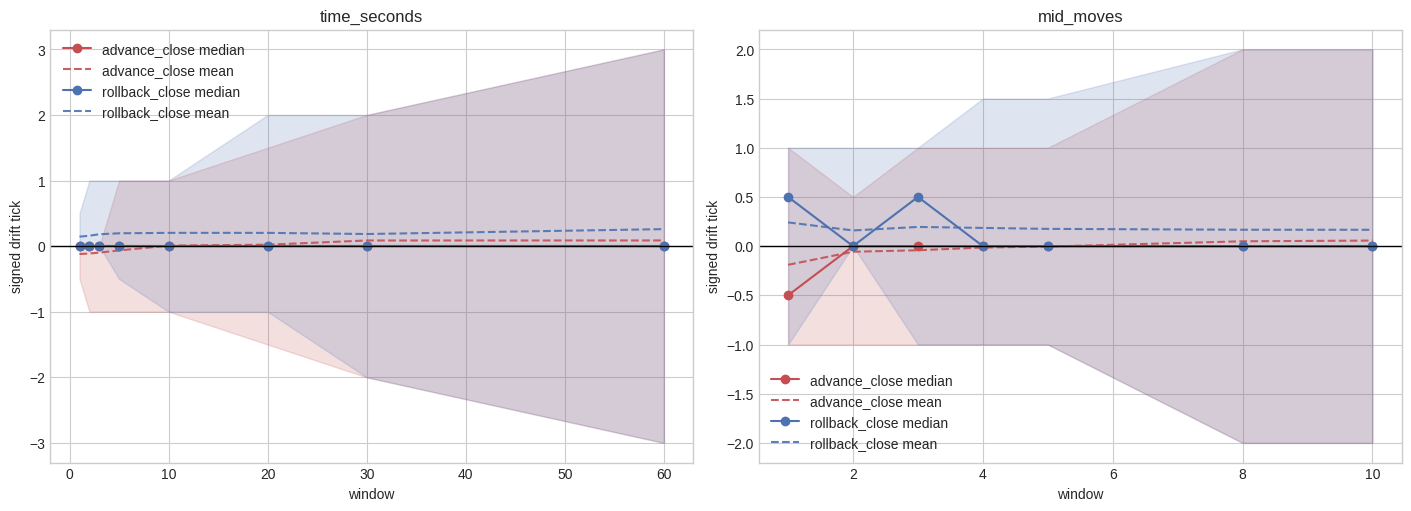

In [4]:
def plot_quantile_bands(horizon_type: str, horizons: list[int], ax):
    subset = quantile_summary[
        (quantile_summary['horizon_type'] == horizon_type)
        & (quantile_summary['horizon_value'].isin(horizons))
    ].copy()
    colors = {
        'advance_close': '#c44e52',
        'rollback_close': '#4c72b0',
    }
    for path_name, g in subset.groupby('resolution_path'):
        g = g.sort_values('horizon_value')
        x = g['horizon_value'].to_numpy(dtype=float)
        ax.plot(x, g['q50_signed_drift_tick'], marker='o', label=f'{path_name} median', color=colors[path_name])
        ax.fill_between(x, g['q25_signed_drift_tick'], g['q75_signed_drift_tick'], alpha=0.18, color=colors[path_name])
        ax.plot(x, g['mean_signed_drift_tick'], linestyle='--', color=colors[path_name], alpha=0.9, label=f'{path_name} mean')
    ax.axhline(0.0, color='black', linewidth=1)
    ax.set_title(horizon_type)
    ax.set_xlabel('window')
    ax.set_ylabel('signed drift tick')
    ax.legend()


fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
plot_quantile_bands('time_seconds', [1, 2, 3, 5, 10, 20, 30, 60], axes[0])
plot_quantile_bands('mid_moves', [1, 2, 3, 4, 5, 8, 10], axes[1])
plt.show()


## 3. 分布图

下面直接画完整分布。横轴是 `signed_post_close_drift_tick`，纵轴是该值出现的样本占比。这样可以直接看到：

- 中心是否集中在 `0`
- `+1` 和 `-1` 哪边更重
- 尾部是单边还是双边扩散


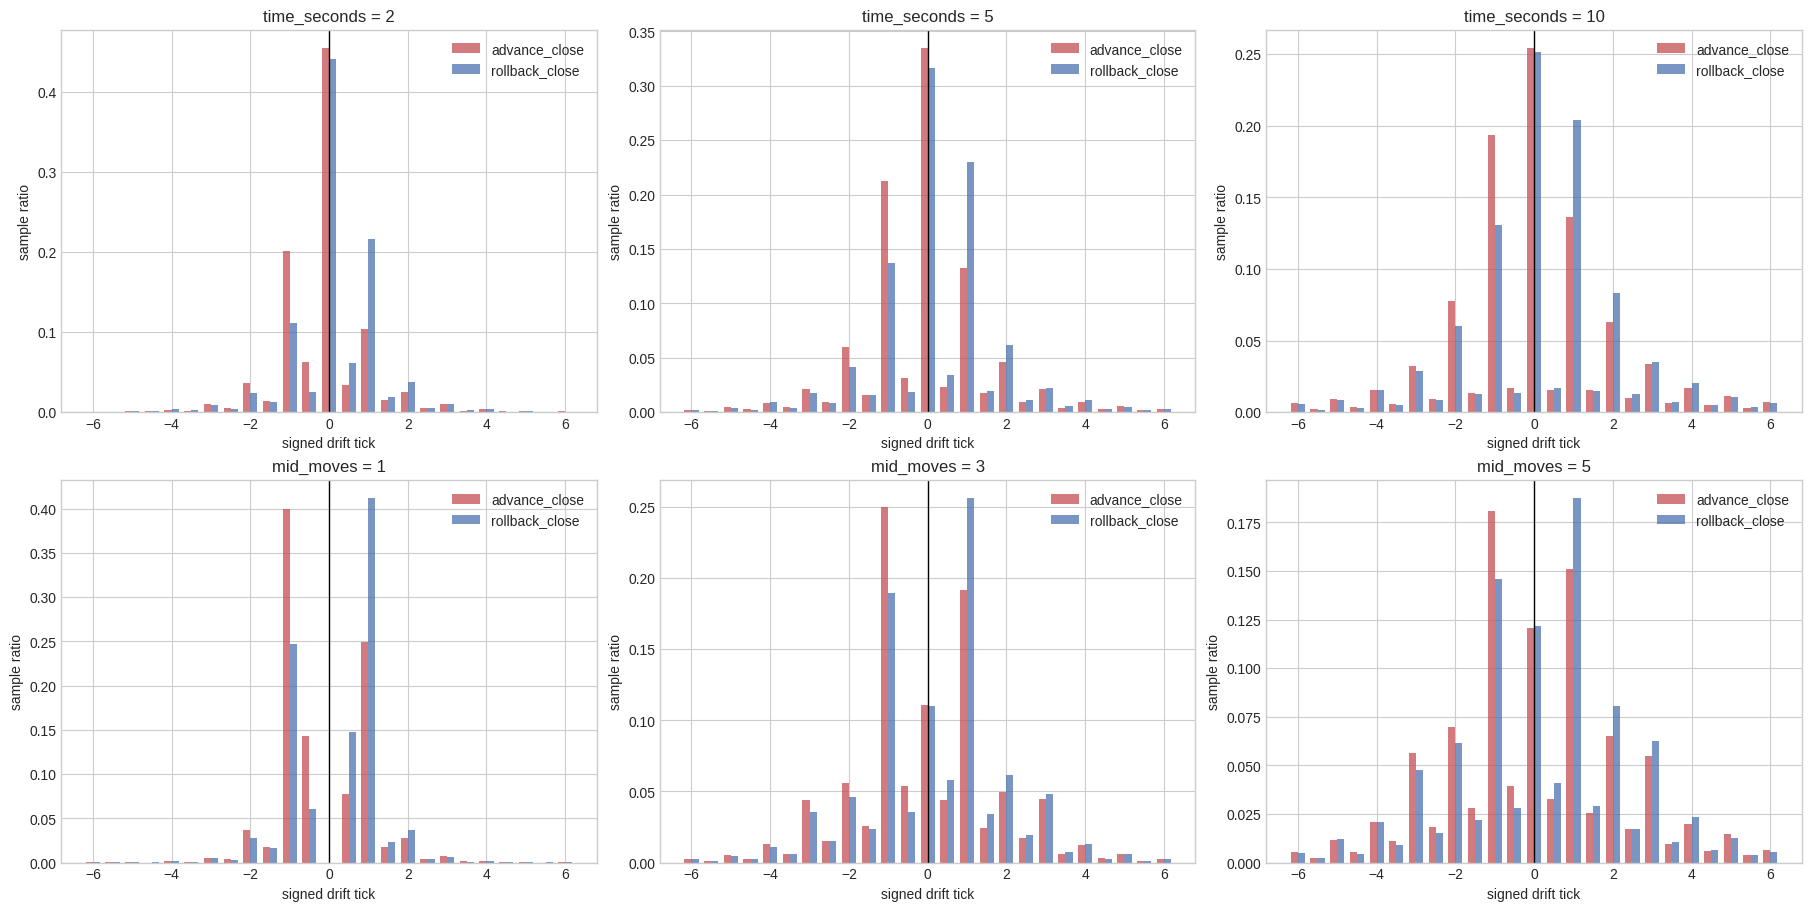

In [5]:
def plot_distribution(horizon_type: str, horizon_value: int, ax, x_clip: float = 6.0):
    subset = value_distribution[
        (value_distribution['horizon_type'] == horizon_type)
        & (value_distribution['horizon_value'] == horizon_value)
        & (value_distribution['signed_post_close_drift_tick'].between(-x_clip, x_clip))
    ].copy()

    pivot = subset.pivot_table(
        index='signed_post_close_drift_tick',
        columns='resolution_path',
        values='sample_ratio',
        fill_value=0.0,
    ).sort_index()

    x = pivot.index.to_numpy(dtype=float)
    width = 0.18
    ax.bar(x - width / 2, pivot.get('advance_close', pd.Series(0.0, index=pivot.index)), width=width, color='#c44e52', alpha=0.75, label='advance_close')
    ax.bar(x + width / 2, pivot.get('rollback_close', pd.Series(0.0, index=pivot.index)), width=width, color='#4c72b0', alpha=0.75, label='rollback_close')
    ax.axvline(0.0, color='black', linewidth=1)
    ax.set_title(f'{horizon_type} = {horizon_value}')
    ax.set_xlabel('signed drift tick')
    ax.set_ylabel('sample ratio')
    ax.legend()


fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
plot_distribution('time_seconds', 2, axes[0, 0])
plot_distribution('time_seconds', 5, axes[0, 1])
plot_distribution('time_seconds', 10, axes[0, 2])
plot_distribution('mid_moves', 1, axes[1, 0])
plot_distribution('mid_moves', 3, axes[1, 1])
plot_distribution('mid_moves', 5, axes[1, 2])
plt.show()


In [6]:
def top_mass_table(horizon_type: str, horizon_value: int, top_n: int = 10) -> pd.DataFrame:
    df = value_distribution[
        (value_distribution['horizon_type'] == horizon_type)
        & (value_distribution['horizon_value'] == horizon_value)
    ].copy()
    return (
        df.sort_values(['resolution_path', 'samples'], ascending=[True, False])
        .groupby('resolution_path', group_keys=False)
        .head(top_n)
        .reset_index(drop=True)
    )


display(top_mass_table('time_seconds', 2, top_n=8))
display(top_mass_table('mid_moves', 1, top_n=8))


,horizon_type,horizon_value,resolution_path,signed_post_close_drift_tick,samples,group_samples,sample_ratio
0,time_seconds,2,advance_close,-0.0000,6920,15206,0.4551
1,time_seconds,2,advance_close,-1.0000,3068,15206,0.2018
2,time_seconds,2,advance_close,1.0000,1580,15206,0.1039
3,time_seconds,2,advance_close,-0.5000,947,15206,0.0623
4,time_seconds,2,advance_close,-2.0000,548,15206,0.0360
5,time_seconds,2,advance_close,0.5000,523,15206,0.0344
6,time_seconds,2,advance_close,2.0000,378,15206,0.0249
7,time_seconds,2,advance_close,1.5000,235,15206,0.0155
8,time_seconds,2,rollback_close,-0.0000,6317,14319,0.4412
9,time_seconds,2,rollback_close,1.0000,3098,14319,0.2164


,horizon_type,horizon_value,resolution_path,signed_post_close_drift_tick,samples,group_samples,sample_ratio
0,mid_moves,1,advance_close,-1.0000,6085,15206,0.4002
1,mid_moves,1,advance_close,1.0000,3796,15206,0.2496
2,mid_moves,1,advance_close,-0.5000,2176,15206,0.1431
3,mid_moves,1,advance_close,0.5000,1177,15206,0.0774
4,mid_moves,1,advance_close,-2.0000,567,15206,0.0373
5,mid_moves,1,advance_close,2.0000,417,15206,0.0274
6,mid_moves,1,advance_close,1.5000,276,15206,0.0182
7,mid_moves,1,advance_close,-1.5000,267,15206,0.0176
8,mid_moves,1,rollback_close,1.0000,5897,14319,0.4118
9,mid_moves,1,rollback_close,-1.0000,3543,14319,0.2474


## 4. 如何读这些图

如果均值是“假的”，常见表现会是：

- 中位数不动，只是极端尾部把均值拖走
- 两边主峰差不多，只是少量离群值不对称

而这组结果里更常见的是：

- `advance_close` 在短窗口上 `-1 tick` 的质量更重
- `rollback_close` 在短窗口上 `+1 tick` 的质量更重
- 很多窗口的中位数虽然是 `0`，但 `+1/-1` 附近的质量已经明显偏斜

所以这里并不只是“均值被少数点带偏”，而是分布本身就有路径依赖。